# AI-Assisted Business Analytics Capstone

**Scenario:** Analyze a small online retail business to understand sales performance and generate AI-assisted business recommendations.

This notebook covers the sales-analysis portion of the capstone and documents the AI, Responsible AI, and privacy activities in the later sections.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

# Resolve the dataset path so the notebook works whether launched from
# the project folder or from the notebooks folder.
candidates = [
    Path("../data/Capstone_Sales_Dataset.csv"),
    Path("data/Capstone_Sales_Dataset.csv"),
    Path("../../data/Capstone_Sales_Dataset.csv"),
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Capstone_Sales_Dataset.csv not found. Put it in the project's data folder.")

PROJECT_ROOT = DATA_PATH.parent.parent
CHARTS_DIR = PROJECT_ROOT / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print("Dataset loaded:", DATA_PATH)
df.head()

Dataset loaded: ..\data\Capstone_Sales_Dataset.csv


,Product Name,Category,Month,Units Sold,Revenue,Region
0,Wireless Mouse,Accessories,January,21,672,North
1,Wireless Mouse,Accessories,February,23,805,South
2,Wireless Mouse,Accessories,March,30,1140,East
3,Wireless Mouse,Accessories,April,19,646,West
4,Wireless Mouse,Accessories,May,26,962,North


## 1. Dataset Inspection

In [2]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes)
print("\nMissing values:")
display(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
display(df.head())

Shape: (40, 6)

Data types:


Product Name    object
Category        object
Month           object
Units Sold       int64
Revenue          int64
Region          object
dtype: object


Missing values:


Product Name    0
Category        0
Month           0
Units Sold      0
Revenue         0
Region          0
dtype: int64


Duplicates: 0


,Product Name,Category,Month,Units Sold,Revenue,Region
0,Wireless Mouse,Accessories,January,21,672,North
1,Wireless Mouse,Accessories,February,23,805,South
2,Wireless Mouse,Accessories,March,30,1140,East
3,Wireless Mouse,Accessories,April,19,646,West
4,Wireless Mouse,Accessories,May,26,962,North


## 2. Sales Analysis

In [3]:
month_order = ["January", "February", "March", "April", "May"]

product_sales = df.groupby("Product Name")["Revenue"].sum().sort_values(ascending=False)
category_sales = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
monthly_sales = df.groupby("Month")["Revenue"].sum().reindex(month_order)
region_sales = df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)

print("Highest revenue product:", product_sales.idxmax())
print("Best category:", category_sales.idxmax())
print("Best month:", monthly_sales.idxmax())
print("Best region:", region_sales.idxmax())

print("\nTotal revenue:", round(df["Revenue"].sum(), 2))
print("Total units sold:", int(df["Units Sold"].sum()))

Highest revenue product: Headphones
Best category: Accessories
Best month: March
Best region: North

Total revenue: 41140
Total units sold: 752


## 3. Required Business Questions

In [4]:
answers = pd.DataFrame({
    "Question": [
        "Product with highest revenue",
        "Best-performing category",
        "Month with highest sales",
        "Best-performing region"
    ],
    "Answer": [
        product_sales.idxmax(),
        category_sales.idxmax(),
        monthly_sales.idxmax(),
        region_sales.idxmax()
    ],
    "Value": [
        product_sales.max(),
        category_sales.max(),
        monthly_sales.max(),
        region_sales.max()
    ]
})
display(answers)

,Question,Answer,Value
0,Product with highest revenue,Headphones,8722
1,Best-performing category,Accessories,15943
2,Month with highest sales,March,11877
3,Best-performing region,North,14242


## 4. Two Required Charts

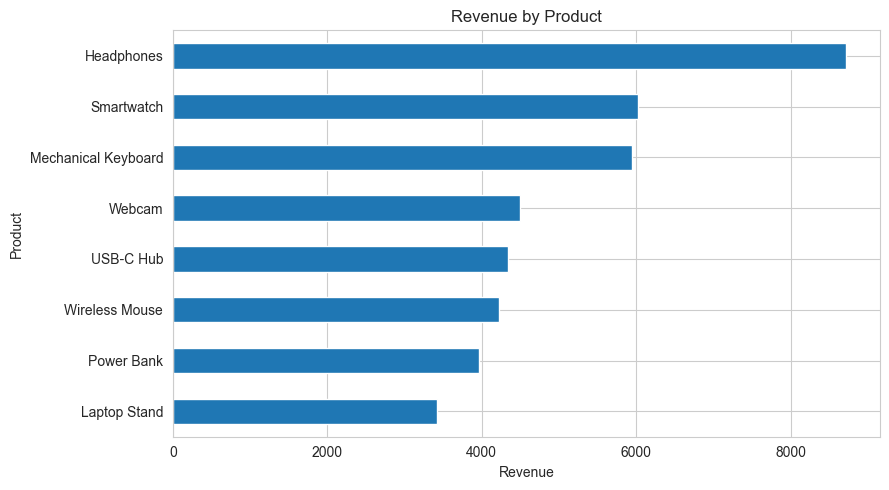

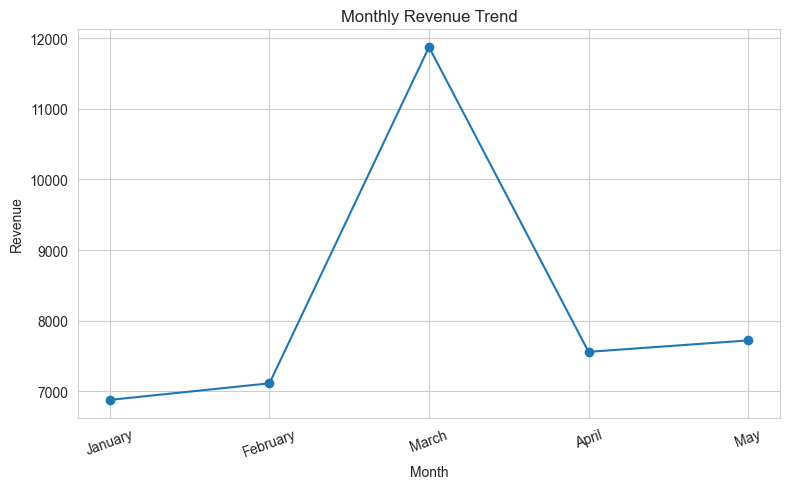

In [5]:
# Chart 1: Revenue by Product
plt.figure(figsize=(9,5))
product_sales.sort_values().plot(kind="barh")
plt.title("Revenue by Product")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "revenue_by_product.png", dpi=200)
plt.show()

# Chart 2: Monthly Revenue Trend
plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "monthly_revenue_trend.png", dpi=200)
plt.show()

## 5. Suggested Sales Actions

1. Promote high-revenue products using targeted offers and bundles.
2. Increase inventory availability in the strongest-performing region and around the strongest sales periods.
3. Review lower-performing products and categories for pricing, promotion, or positioning improvements.

## 6. Five AI Prompts

### Prompt 1 — Sales Analysis
**Purpose:** Summarize overall sales performance from a structured dataset.

**Prompt:**
> Analyze the sales dataset and summarize total revenue, units sold, best-performing products, categories, months, and regions. Present the results in a concise business table.

**Output generated:** A structured sales summary and performance table.

**Business value:** Helps management quickly identify major sales drivers.

### Prompt 2 — Product Performance
**Purpose:** Identify strong and weak products.

**Prompt:**
> Compare products by total revenue and units sold. Identify the strongest and weakest products and explain what management should investigate.

**Output generated:** Product ranking with observations.

**Business value:** Supports product and inventory decisions.

### Prompt 3 — Monthly Sales Trend
**Purpose:** Interpret sales movement over time.

**Prompt:**
> Analyze monthly revenue and identify the highest and lowest sales months. Suggest practical reasons that management should investigate for the observed pattern.

**Output generated:** Trend summary and investigation areas.

**Business value:** Supports sales planning and campaign timing.

### Prompt 4 — Customer Feedback
**Purpose:** Turn customer feedback into themes.

**Prompt:**
> Group customer feedback into major themes, identify recurring complaints and positive themes, and suggest operational actions for each theme. Do not expose personal customer information.

**Output generated:** Feedback themes and actions.

**Business value:** Helps prioritize customer-experience improvements.

### Prompt 5 — Business Recommendation
**Purpose:** Generate actionable recommendations from the analysis.

**Prompt:**
> Based only on the provided sales analysis, propose five practical business recommendations. For each recommendation, state the evidence, expected business impact, and a measurable KPI.

**Output generated:** Evidence-based recommendation table.

**Business value:** Converts analysis into management actions.

## 7. Prompt Engineering — Basic vs Improved

### Comparison 1 — Sales Analysis

**Basic prompt:**
> Analyze these sales numbers.

**Improved prompt:**
> Analyze the provided sales dataset. Calculate total revenue and units sold, rank products and categories by revenue, identify the highest-sales month and region, and present the results in a table. State assumptions clearly and do not invent values.

**Comparison:** The improved prompt is more structured and constrained, so the expected output is more accurate, detailed, and directly useful for business analysis.

### Comparison 2 — Business Recommendations

**Basic prompt:**
> Give recommendations to improve sales.

**Improved prompt:**
> Using only the observed sales results, give five recommendations to improve sales. For each, include the supporting evidence, the business action, an expected impact, and one KPI that management can monitor. Avoid unsupported claims and clearly identify recommendations that require further validation.

**Comparison:** The improved prompt requests evidence, actions, impact, and KPIs, making the output more specific and easier to evaluate.

## 8. Responsible AI

**Difficult question:**
> Predict next year's sales with complete accuracy.

**Was the response reliable?** No. A model cannot guarantee an exact future sales forecast from limited historical information.

**Limitations:** Forecasts depend on historical data quality, seasonality, customer behavior, market conditions, competition, pricing, campaigns, and other variables that may change.

**Why humans should verify AI output:** Business decisions affect budgets, inventory, staffing, and customers. Human review is needed to check assumptions, validate evidence, consider current context, and assess risks before acting on AI-generated output.

## 9. Data Privacy

### Sensitive customer information
Names, email addresses, phone numbers, home addresses, payment details, account identifiers, and other information that can directly identify or materially profile a customer should not be copied into general-purpose AI tools without appropriate authorization and safeguards.

### Protection
Use data minimization, remove or mask direct identifiers, restrict access, follow organizational privacy policies, and share only the fields necessary for the analysis.

### Why privacy matters
Protecting customer information reduces the risk of unauthorized disclosure, misuse, and loss of trust, and supports responsible handling of business data.

## 10. Final Recommendations

1. Focus marketing and merchandising on high-revenue products while monitoring inventory.
2. Use the strongest-performing region as a reference point when evaluating weaker regions.
3. Plan promotions around observed high-sales periods while investigating seasonality before scaling campaigns.
4. Use AI outputs as decision support rather than as an automatic replacement for human judgment.
5. Apply data minimization and privacy controls whenever customer data is analyzed with AI tools.

## 11. Conclusion

The project combines basic sales analytics with practical generative-AI and responsible-AI practices. The analysis identifies key sales drivers, while the prompt-engineering and privacy sections show how AI can be used with clearer instructions, human validation, and appropriate data protection.